===========================================
PREPROCESAMIENTO - PROYECTO PREDICCIÓN DE ICTUS
Hospital F5 - Preparación de Datos para Modelado
===========================================

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [12]:
# ===========================================
# 1. CARGA DE DATOS
# ===========================================
print("\n📁 1. CARGANDO DATOS...")

import os

# Cargar dataset local desde la carpeta data
base_dir = os.path.dirname(os.getcwd())  # sube un nivel (de notebooks a raíz)
data_path = os.path.join(base_dir, 'data', 'stroke_dataset.csv')

df = pd.read_csv(data_path)

print(f"✅ Dataset cargado desde: {data_path}")
print(f"   {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"   Distribución original: {df['stroke'].value_counts()[0]} sin ictus, {df['stroke'].value_counts()[1]} con ictus")

# Crear copia para preservar datos originales
df_original = df.copy()



📁 1. CARGANDO DATOS...
✅ Dataset cargado desde: /home/noe/Documentos/F5/project-ai-data-scientistG2/data/stroke_dataset.csv
   4981 filas, 11 columnas
   Distribución original: 4733 sin ictus, 248 con ictus


In [13]:
# ===========================================
# 2. FEATURE ENGINEERING
# ===========================================
print("\n" + "="*60)
print("⚙️ 3. FEATURE ENGINEERING")
print("="*60)

# 3.1 Crear rangos de edad
df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 18, 35, 50, 65, 100],
                         labels=['0-18', '19-35', '36-50', '51-65', '65+'])

print("\n✅ Rangos de edad creados:")
print(df['age_group'].value_counts().sort_index())

# 3.2 Crear feature combinado de factores de riesgo
df['risk_factors'] = df['hypertension'] + df['heart_disease']
print(f"\n✅ Feature 'risk_factors' creado (suma de hipertensión y enfermedad cardíaca)")
print(f"   Distribución: {df['risk_factors'].value_counts().sort_index().to_dict()}")

# 3.3 Crear categorías de BMI según estándares médicos
df['bmi_category'] = pd.cut(df['bmi'],
                            bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

print(f"\n✅ Categorías de BMI creadas:")
print(df['bmi_category'].value_counts())

# 3.4 Crear categorías de glucosa
df['glucose_category'] = pd.cut(df['avg_glucose_level'],
                                bins=[0, 100, 125, 300],
                                labels=['Normal', 'Prediabetes', 'Diabetes'])

print(f"\n✅ Categorías de glucosa creadas:")
print(df['glucose_category'].value_counts())

# 3.5 Crear interacción edad-factores de riesgo
df['age_risk_interaction'] = df['age'] * df['risk_factors']

print(f"\n✅ Interacción edad-riesgo creada")



⚙️ 3. FEATURE ENGINEERING

✅ Rangos de edad creados:
age_group
0-18      880
19-35     961
36-50    1047
51-65    1134
65+       959
Name: count, dtype: int64

✅ Feature 'risk_factors' creado (suma de hipertensión y enfermedad cardíaca)
   Distribución: {0: 4291, 1: 626, 2: 64}

✅ Categorías de BMI creadas:
bmi_category
Obese          1888
Overweight     1500
Normal         1261
Underweight     332
Name: count, dtype: int64

✅ Categorías de glucosa creadas:
glucose_category
Normal         3061
Diabetes        964
Prediabetes     956
Name: count, dtype: int64

✅ Interacción edad-riesgo creada


In [14]:
# ===========================================
# 3. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ===========================================
print("\n" + "="*60)
print("🔤 4. CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*60)

# 4.1 Variables binarias (Label Encoding)
binary_cols = ['gender', 'ever_married', 'Residence_type']

le = LabelEncoder()
for col in binary_cols:
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    print(f"✅ {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 4.2 Variables con múltiples categorías (One-Hot Encoding)
categorical_cols = ['work_type', 'smoking_status', 'age_group', 'bmi_category', 'glucose_category']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print(f"\n✅ One-Hot Encoding aplicado a: {categorical_cols}")
print(f"   Columnas después de encoding: {df_encoded.shape[1]}")


🔤 4. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
✅ gender: {'Female': np.int64(0), 'Male': np.int64(1)}
✅ ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}

✅ One-Hot Encoding aplicado a: ['work_type', 'smoking_status', 'age_group', 'bmi_category', 'glucose_category']
   Columnas después de encoding: 29


In [15]:
# ===========================================
# 4. ELIMINACIÓN DE COLUMNAS REDUNDANTES
# ===========================================
print("\n" + "="*60)
print("🗑️ 5. ELIMINACIÓN DE COLUMNAS REDUNDANTES")
print("="*60)

# Columnas originales categóricas ya codificadas
cols_to_drop = binary_cols + []

df_encoded = df_encoded.drop(columns=cols_to_drop)

print(f"✅ Columnas eliminadas: {cols_to_drop}")
print(f"   Columnas restantes: {df_encoded.shape[1]}")
print(f"\nColumnas finales:")
print(df_encoded.columns.tolist())


🗑️ 5. ELIMINACIÓN DE COLUMNAS REDUNDANTES
✅ Columnas eliminadas: ['gender', 'ever_married', 'Residence_type']
   Columnas restantes: 26

Columnas finales:
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'risk_factors', 'age_risk_interaction', 'gender_encoded', 'ever_married_encoded', 'Residence_type_encoded', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'age_group_19-35', 'age_group_36-50', 'age_group_51-65', 'age_group_65+', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese', 'glucose_category_Prediabetes', 'glucose_category_Diabetes']


In [16]:
# ===========================================
# 6. DIVISIÓN DE DATOS (TRAIN/TEST)
# ===========================================
print("\n" + "="*60)
print("✂️ 6. DIVISIÓN TRAIN/TEST")
print("="*60)

# Separar features y target
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

# División estratificada (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n✅ División completada:")
print(f"   Train: {X_train.shape[0]} muestras ({y_train.sum()} con ictus)")
print(f"   Test:  {X_test.shape[0]} muestras ({y_test.sum()} con ictus)")
print(f"\n   Proporción en Train: {y_train.value_counts()[1]/len(y_train)*100:.2f}% con ictus")
print(f"   Proporción en Test:  {y_test.value_counts()[1]/len(y_test)*100:.2f}% con ictus")



✂️ 6. DIVISIÓN TRAIN/TEST

✅ División completada:
   Train: 3984 muestras (198 con ictus)
   Test:  997 muestras (50 con ictus)

   Proporción en Train: 4.97% con ictus
   Proporción en Test:  5.02% con ictus


In [17]:
# ===========================================
# 6. ESCALADO DE VARIABLES NUMÉRICAS
# ===========================================
print("\n" + "="*60)
print("📊 7. ESCALADO DE VARIABLES NUMÉRICAS")
print("="*60)

# Identificar SOLO columnas numéricas continuas (NO binarias)
numeric_features = ['age', 'avg_glucose_level', 'bmi', 'age_risk_interaction']

# Crear copias para no modificar los DataFrames originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Escalado con StandardScaler SOLO en columnas numéricas
scaler = StandardScaler()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# Reemplazar los DataFrames
X_train = X_train_scaled
X_test = X_test_scaled

print(f"✅ Escalado aplicado SOLO a variables numéricas continuas:")
print(f"   {numeric_features}")
print(f"\n✅ Variables binarias (one-hot encoding) NO escaladas")
print(f"\nEstadísticas después del escalado (Train):")
print(X_train[numeric_features].describe())


📊 7. ESCALADO DE VARIABLES NUMÉRICAS
✅ Escalado aplicado SOLO a variables numéricas continuas:
   ['age', 'avg_glucose_level', 'bmi', 'age_risk_interaction']

✅ Variables binarias (one-hot encoding) NO escaladas

Estadísticas después del escalado (Train):
                age  avg_glucose_level           bmi  age_risk_interaction
count  3.984000e+03       3.984000e+03  3.984000e+03          3.984000e+03
mean   6.509741e-17       5.194417e-17 -3.879092e-16          1.016590e-16
std    1.000126e+00       1.000126e+00  1.000126e+00          1.000126e+00
min   -1.923984e+00      -1.129200e+00 -2.157245e+00         -3.722351e-01
25%   -7.784082e-01      -6.372148e-01 -6.925215e-01         -3.722351e-01
50%    6.132722e-02      -3.127705e-01 -5.632865e-02         -3.722351e-01
75%    7.684728e-01       1.759076e-01  6.094546e-01         -3.722351e-01
max    1.696601e+00       3.558407e+00  3.006274e+00          5.827501e+00



📈 8. VISUALIZACIÓN DE RESULTADOS


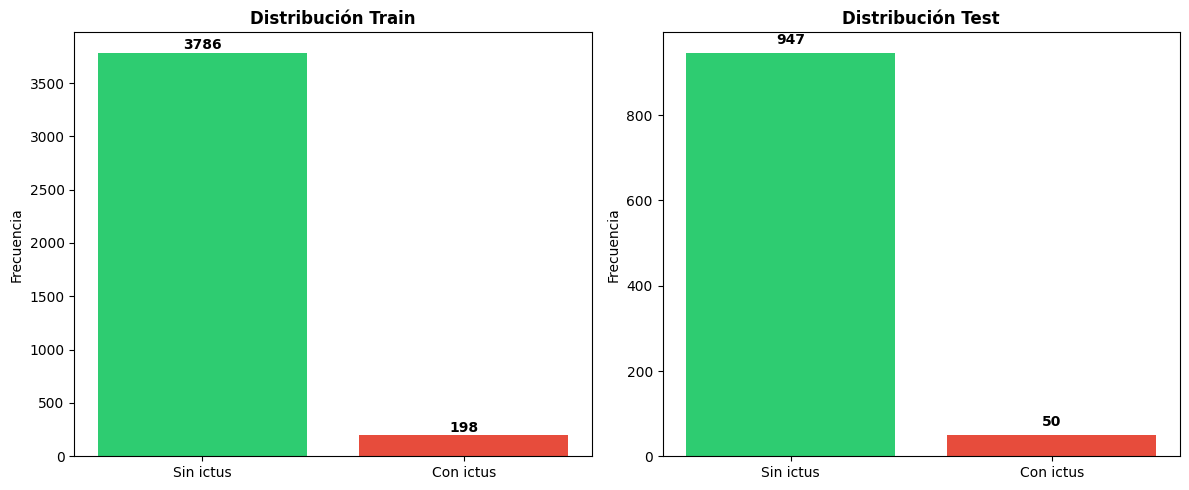

In [8]:
# ===========================================
# 8. VISUALIZACIÓN DEL PREPROCESAMIENTO
# ===========================================
print("\n" + "="*60)
print("📈 8. VISUALIZACIÓN DE RESULTADOS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribución Train
axes[0].bar(['Sin ictus', 'Con ictus'], y_train.value_counts().values, 
               color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución Train', fontweight='bold')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(y_train.value_counts().values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Distribución Test
axes[1].bar(['Sin ictus', 'Con ictus'], y_test.value_counts().values, 
               color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribución Test', fontweight='bold')
axes[1].set_ylabel('Frecuencia')
for i, v in enumerate(y_test.value_counts().values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# ===========================================
# 9. GUARDAR DATOS PREPROCESADOS
# ===========================================
print("\n" + "="*60)
print("💾 9. GUARDADO DE DATOS PREPROCESADOS")
print("="*60)

import os
import pickle

# Crear la carpeta 'processed' dentro de 'data'
base_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(base_dir, 'data')
processed_dir = os.path.join(data_dir, 'processed')

# Crear carpetas si no existen
os.makedirs(processed_dir, exist_ok=True)

# Rutas de archivos
pkl_path = os.path.join(processed_dir, 'preprocessed_data.pkl')

# Guardar datasets en formato pickle (mantener estructura compatible con modelos)
datasets = {
    'original': (X_train, X_test, y_train, y_test),
    'scaler': scaler,
    'feature_names': X_train.columns.tolist()
}

with open(pkl_path, 'wb') as f:
    pickle.dump(datasets, f)

print(f"✅ Datos guardados en '{pkl_path}'")

# Guardar CSVs procesados con las 25 features que el modelo espera
train_processed = X_train.copy()
train_processed['stroke'] = y_train.values

test_processed = X_test.copy()
test_processed['stroke'] = y_test.values

train_csv_path = os.path.join(processed_dir, 'stroke_data_processed.csv')
test_csv_path = os.path.join(processed_dir, 'stroke_data_processed_test.csv')

train_processed.to_csv(train_csv_path, index=False)
test_processed.to_csv(test_csv_path, index=False)

print(f"✅ stroke_data_processed.csv: {train_processed.shape}")
print(f"   Guardado en: {train_csv_path}")
print(f"   Features: {train_processed.shape[1] - 1} (sin stroke)")
print(f"\n✅ stroke_data_processed_test.csv: {test_processed.shape}")
print(f"   Guardado en: {test_csv_path}")
print(f"   Features: {test_processed.shape[1] - 1} (sin stroke)")


💾 9. GUARDADO DE DATOS PREPROCESADOS
✅ Datos guardados en '/home/noe/Documentos/F5/project-ai-data-scientistG2/data/processed/preprocessed_data.pkl'
✅ stroke_data_processed.csv: (3984, 26)
   Guardado en: /home/noe/Documentos/F5/project-ai-data-scientistG2/data/processed/stroke_data_processed.csv
   Features: 25 (sin stroke)

✅ stroke_data_processed_test.csv: (997, 26)
   Guardado en: /home/noe/Documentos/F5/project-ai-data-scientistG2/data/processed/stroke_data_processed_test.csv
   Features: 25 (sin stroke)


In [19]:
# ===========================================
# 10. RESUMEN FINAL
# ===========================================
print("\n" + "="*60)
print("📋 10. RESUMEN DEL PREPROCESAMIENTO")
print("="*60)

print(f"""
✅ PREPROCESAMIENTO COMPLETADO

📊 DATOS FINALES:
   - Features totales: {X_train.shape[1]}
   - Train: {X_train.shape[0]} muestras ({y_train.sum()} con ictus)
   - Test: {X_test.shape[0]} muestras ({y_test.sum()} con ictus)

🔧 TRANSFORMACIONES APLICADAS:
   ✅ Feature engineering (rangos de edad, categorías BMI/glucosa, interacciones)
   ✅ Codificación de variables categóricas (Label + One-Hot Encoding)
   ✅ Escalado de variables numéricas (StandardScaler)

📁 ARCHIVOS GENERADOS EN data/processed/:
   - preprocessed_data.pkl
   - stroke_data_processed.csv
   - stroke_data_processed_test.csv

🎯 PRÓXIMOS PASOS:
   - El balanceo de clases (SMOTE) se aplicará en cada modelo
   - Entrenar modelos con diferentes técnicas de balanceo
   - Optimización de hiperparámetros
   - Evaluación con métricas enfocadas en RECALL
""")

print("="*60)
print("✅ PREPROCESAMIENTO FINALIZADO")
print("="*60)


📋 10. RESUMEN DEL PREPROCESAMIENTO

✅ PREPROCESAMIENTO COMPLETADO

📊 DATOS FINALES:
   - Features totales: 25
   - Train: 3984 muestras (198 con ictus)
   - Test: 997 muestras (50 con ictus)

🔧 TRANSFORMACIONES APLICADAS:
   ✅ Feature engineering (rangos de edad, categorías BMI/glucosa, interacciones)
   ✅ Codificación de variables categóricas (Label + One-Hot Encoding)
   ✅ Escalado de variables numéricas (StandardScaler)

📁 ARCHIVOS GENERADOS EN data/processed/:
   - preprocessed_data.pkl
   - stroke_data_processed.csv
   - stroke_data_processed_test.csv

🎯 PRÓXIMOS PASOS:
   - El balanceo de clases (SMOTE) se aplicará en cada modelo
   - Entrenar modelos con diferentes técnicas de balanceo
   - Optimización de hiperparámetros
   - Evaluación con métricas enfocadas en RECALL

✅ PREPROCESAMIENTO FINALIZADO
